![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [1]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [13]:
#Note cannot use Alaska hear, Alaska is not in the NLDI!!
nldi = NLDI()
usgs_gage_id = "10105900" #Little Bear River at Paradise, UT - USGS-10105900
WY = 2019 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

## Getting additional data, Lets go from Snow to Flow!

Lets grab streamflow data using the USGS NWIS Data retrieval script





In [14]:
#get streamflow information using the NWIS id for the gage and ghte get_usgs_streamflow function in getData.py 
streamflow = getData.get_usgs_streamflow(usgs_gage_id)

Retrieving data for Site: 10105900 from 1980-01-01 to 2026-03-25...


In [15]:
streamflow.head()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
1991-10-01 00:00:00+00:00,10105900,77.0,A
1991-10-02 00:00:00+00:00,10105900,77.0,A
1992-10-01 00:00:00+00:00,10105900,9.0,A
1992-10-02 00:00:00+00:00,10105900,8.6,A
1992-10-03 00:00:00+00:00,10105900,10.0,A


In [16]:
streamflow.tail()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2026-03-20 00:00:00+00:00,10105900,75.3,P
2026-03-21 00:00:00+00:00,10105900,81.7,P
2026-03-22 00:00:00+00:00,10105900,88.4,P
2026-03-23 00:00:00+00:00,10105900,89.1,P
2026-03-24 00:00:00+00:00,10105900,89.7,P


## Clean the data

We need to change the index to a datetime indexand clean it to just the date. We do not need the 00060_Mean_cd column, and we should change it to streamflow in cfs

In [17]:

cleaned = dataprocessing.clean_nwis_dataframe(streamflow)
#set the index name to Date

cleaned.index.name = "Date"
cleaned.head()

,site_no,flow_cfs
Date,,
1991-10-01,10105900,77.0
1991-10-02,10105900,77.0
1992-10-01,10105900,9.0
1992-10-02,10105900,8.6
1992-10-03,10105900,10.0


In [18]:
#our other measurements are all in SI units, lets convert cfs to cms
cleaned['flow_cfs'] = cleaned['flow_cfs'] * 0.0283168
cleaned.rename(columns={'flow_cfs': 'flow_cms'}, inplace=True)

## Plot the data


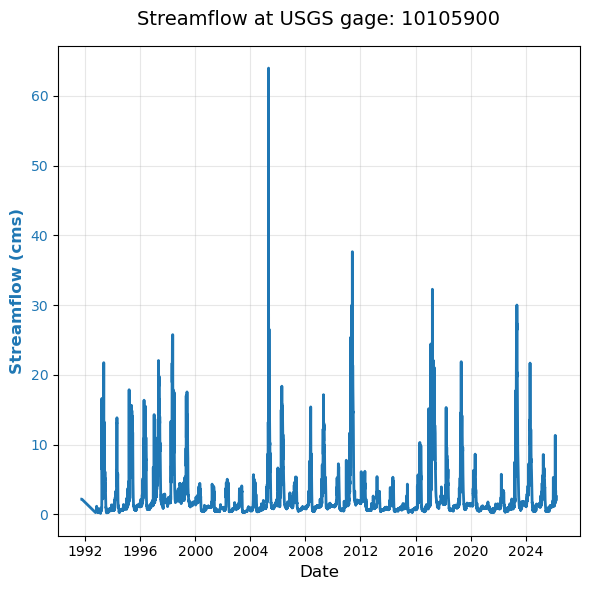

In [19]:
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cms)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(cleaned.index, cleaned['flow_cms'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

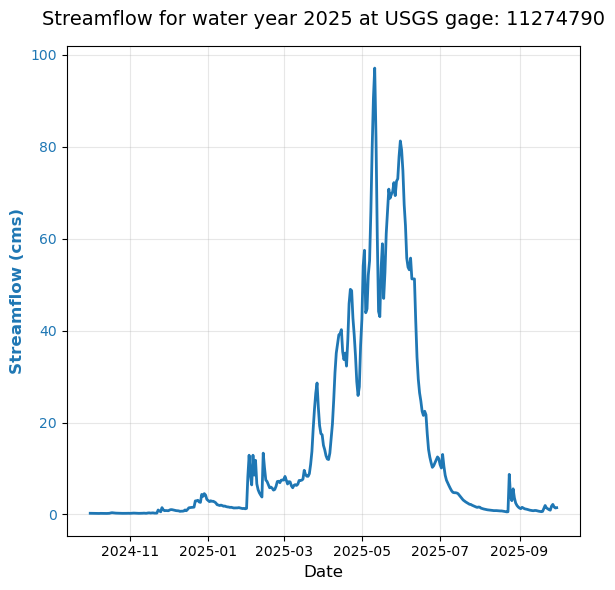

In [11]:
#clip the dataframe to show one single year
start = '2024-10-01'
end = '2025-09-30'
WY_df = cleaned.loc[start:end]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cms)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(WY_df.index, WY_df['flow_cms'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow for water year 2025 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

In [20]:
#save the cleaned dataframe to a csv file
# Use the getData module to retrieve data 
OutputFolder = 'files/NWIS'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
cleaned.to_csv(f'{OutputFolder}/streamflow_{usgs_gage_id}.csv')

## We now have a simple script for collecting streamflow data

The next step will be to get meteorological information for this basin, the [Met_data.ipynb](Met_data.ipynb) will use the basin information to get the appropriate daily precipitation and temperature information.